# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`: Anjelica
**`Roll Number`: U20230145
**`GitHub Branch`:** anelica_U20230145  

# Imports and Setup

In [1]:
! pip install rlcmab-sampler

In [2]:
! pip install pandas
! pip install matplotlib
! pip install scikit-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler


# Load Datasets

In [4]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())

print(f"\nShape: {news_df.shape}")
print(f"\nColumns: {news_df.columns.tolist()}")


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

In [5]:
print(train_users.head())
print(f"\nShape: {train_users.shape}")
print(f"\nColumns: {train_users.columns.tolist()}")

  user_id   age  income  clicks  purchase_amount  session_duration  \
0   U7392   NaN   23053      10           500.00             17.34   
1   U2702  56.0   20239      11           913.33             22.22   
2   U2461   NaN   13907       9          1252.62             41.57   
3   U7475   NaN   26615      12           500.00             30.17   
4   U6040  32.0   27958      13           500.00             65.27   

   content_variety  engagement_score  num_transactions  avg_monthly_spend  \
0          0.36661          37.29781                 3             187.44   
1          0.61370          59.36342                 5             145.15   
2          0.80368          76.78706                 7             282.03   
3          0.26499          30.19441                10             195.35   
4          0.36385          37.12153                 5             439.68   

   ...  screen_brightness  battery_percentage  cart_abandonment_count  \
0  ...                4.0                 2

In [6]:
print("\nTest Users Dataset:")
print(test_users.head())
print(f"\nShape: {test_users.shape}")


Test Users Dataset:
  user_id   age  income  clicks  purchase_amount  session_duration  \
0   U4058  36.0   10000       4           500.00              2.54   
1   U1118  33.0   19607       8          1906.81             39.74   
2   U6555  51.0   21049      11           500.00             46.07   
3   U9170  58.0   25752      13           500.00             60.86   
4   U3348  32.0   25302      12          2693.22             39.77   

   content_variety  engagement_score  num_transactions  avg_monthly_spend  \
0          0.47162          49.32668                 8             229.80   
1          0.55219          56.42526                 4             819.43   
2          0.69961          58.88307                 5             113.35   
3          0.86843          86.15690                 8             237.13   
4          0.81805          84.82418                 5            1491.56   

   ...  loyalty_index  screen_brightness  battery_percentage  \
0  ...           13.0          

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [7]:
print("="*60)
print("DATA PREPROCESSING - STEP 5.1")
print("="*60)

# Check for missing values
print("\n1. Checking for missing values...")
print("\nMissing values in train_users:")
print(train_users.isnull().sum())

print("\nMissing values in test_users:")
print(test_users.isnull().sum())

print("\nMissing values in news_df:")
print(news_df.isnull().sum())

DATA PREPROCESSING - STEP 5.1

1. Checking for missing values...

Missing values in train_users:
user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment_count      

In [8]:
# First, explore the actual categories in the dataset
print("="*60)
print("EXPLORING NEWS CATEGORIES")
print("="*60)

print("\nOriginal categories in news dataset:")
print(news_df['category'].value_counts())
print(f"\nTotal unique categories: {news_df['category'].nunique()}")
print(f"Total articles: {len(news_df)}")

# Get all unique categories
all_categories = news_df['category'].unique()
print(f"\nAll categories:\n{sorted(all_categories)}")

EXPLORING NEWS CATEGORIES

Original categories in news dataset:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE        

In [9]:
print("\n2. Handling missing values...")

numeric_cols = train_users.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if train_users[col].isnull().sum() > 0:
        median_val = train_users[col].median()
        train_users[col] = train_users[col].fillna(median_val)
        test_users[col] = test_users[col].fillna(median_val)
        print(f"   Filled {col} with median: {median_val:.2f}")

print("✓ Missing values handled")


2. Handling missing values...
   Filled age with median: 39.00
✓ Missing values handled


In [10]:
print("\n3. Exploring news categories...")
print("\nOriginal categories in news dataset:")
print(news_df['category'].value_counts())
print(f"\nTotal unique categories: {news_df['category'].nunique()}")
print(f"Total articles: {len(news_df)}")

print("\n4. Mapping news categories to 4 main categories...")

category_mapping = {
    # Entertainment
    'ENTERTAINMENT': 'Entertainment',
    'COMEDY': 'Entertainment',
    'PARENTING': 'Entertainment',
    'STYLE & BEAUTY': 'Entertainment',
    'FOOD & DRINK': 'Entertainment',
    'TRAVEL': 'Entertainment',
    'WEDDINGS': 'Entertainment',
    'HOME & LIVING': 'Entertainment',
    'ARTS': 'Entertainment',
    'CULTURE & ARTS': 'Entertainment',
    'MEDIA': 'Entertainment',
    'TASTE': 'Entertainment',
    
    # Education
    'EDUCATION': 'Education',
    'COLLEGE': 'Education',
    'PARENTS': 'Education',
    'WELLNESS': 'Education',
    'HEALTHY LIVING': 'Education',
    'QUEER VOICES': 'Education',
    'RELIGION': 'Education',
    
    # Tech
    'TECH': 'Tech',
    'SCIENCE': 'Tech',
    'BUSINESS': 'Tech',
    'MONEY': 'Tech',
    'ENVIRONMENT': 'Tech',
    'GREEN': 'Tech',
    
    # Crime (and related news/politics categories)
    'CRIME': 'Crime',
    'POLITICS': 'Crime',
    'U.S. NEWS': 'Crime',
    'WORLD NEWS': 'Crime',
    'WORLDPOST': 'Crime',
    'BLACK VOICES': 'Crime',
    'LATINO VOICES': 'Crime',
    'WOMEN': 'Crime',
    'IMPACT': 'Crime',
    'DIVORCE': 'Crime',
    'FIFTY': 'Crime',
    'GOOD NEWS': 'Crime',
    'THE WORLDPOST': 'Crime',
    'WEIRD NEWS': 'Crime'
}

# Apply mapping
news_df['mapped_category'] = news_df['category'].map(category_mapping)

# Handle any unmapped categories (assign to Entertainment as default)
unmapped = news_df['mapped_category'].isnull().sum()
if unmapped > 0:
    print(f"   Found {unmapped} unmapped categories, assigning to Entertainment")
    news_df['mapped_category'] = news_df['mapped_category'].fillna('Entertainment')

print("\nMapped category distribution:")
print(news_df['mapped_category'].value_counts())
print("✓ Categories mapped to 4 main types")

print("\n5. Encoding user labels...")

label_encoder = LabelEncoder()
train_users['label_encoded'] = label_encoder.fit_transform(train_users['label'])

# Check if test_users has labels (it shouldn't for a real test set)
if 'label' in test_users.columns:
    test_users['label_encoded'] = label_encoder.transform(test_users['label'])
    print("   Test set has labels (for evaluation purposes)")
else:
    print("   Test set has no labels (as expected for real-world scenario)")

print("\nLabel encoding mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

# %%
# Prepare features and labels for classification
print("\n6. Preparing features for classification...")

feature_cols = ['age', 'income', 'clicks', 'purchase_amount']

# Training data
X_train = train_users[feature_cols].values
y_train = train_users['label_encoded'].values

# Test data (features only, may not have labels)
X_test = test_users[feature_cols].values
y_test = test_users['label_encoded'].values if 'label_encoded' in test_users.columns else None

print(f"\nFull training data: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test data: {X_test.shape}")
if y_test is not None:
    print(f"Test labels: {y_test.shape}")
else:
    print("Test labels: Not available")

# Display class distribution
print("\nClass distribution in full training data:")
unique, counts = np.unique(y_train, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {label_encoder.classes_[label_idx]}: {count} ({count/len(y_train)*100:.1f}%)")

if y_test is not None:
    print("\nClass distribution in test data:")
    unique, counts = np.unique(y_test, return_counts=True)
    for label_idx, count in zip(unique, counts):
        print(f"  {label_encoder.classes_[label_idx]}: {count} ({count/len(y_test)*100:.1f}%)")




3. Exploring news categories...

Original categories in news dataset:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE 


7. Visualizing feature distributions...


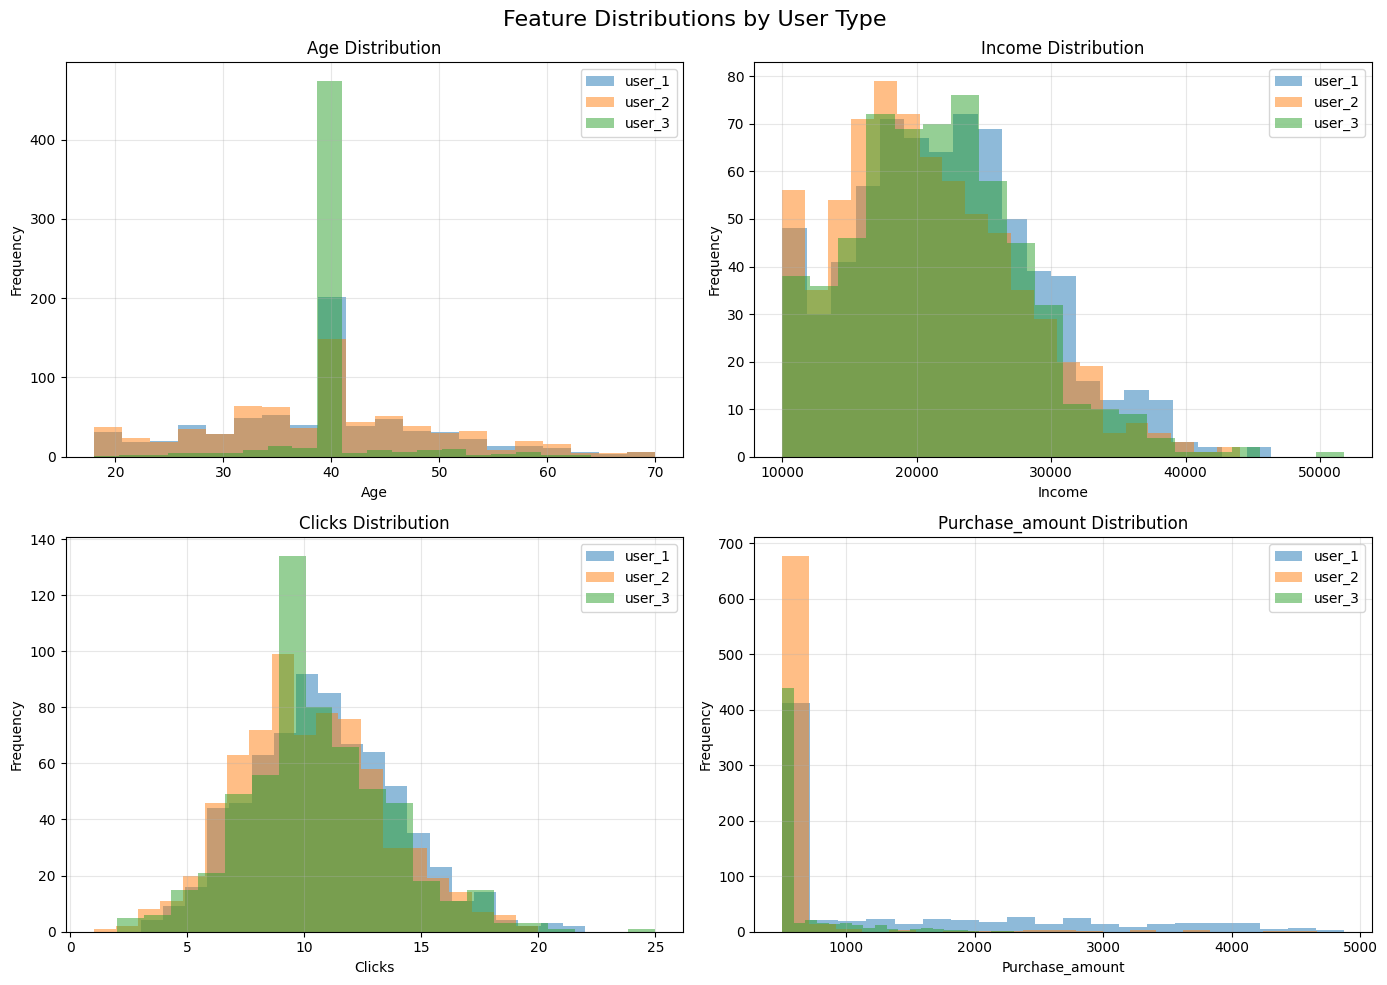

In [11]:
print("\n7. Visualizing feature distributions...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by User Type', fontsize=16)

for idx, feature in enumerate(feature_cols):
    ax = axes[idx // 2, idx % 2]
    
    for user_type in label_encoder.classes_:
        user_idx = label_encoder.transform([user_type])[0]
        data = train_users[train_users['label_encoded'] == user_idx][feature]
        ax.hist(data, alpha=0.5, label=user_type, bins=20)
    
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature.capitalize()} Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, 
    y_train, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train  # Ensure balanced split across classes
)

print("="*60)
print("TRAIN-VALIDATION SPLIT")
print("="*60)
print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train_split, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {label_encoder.classes_[label_idx]}: {count}")


classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    
    # Train the classifier
    clf.fit(X_train_split, y_train_split)
    
    # Predict on validation set
    y_val_pred = clf.predict(X_val_split)
    
    # Calculate accuracy
    val_accuracy = accuracy_score(y_val_split, y_val_pred)
    
    # Also evaluate on training set to check for overfitting
    y_train_pred = clf.predict(X_train_split)
    train_accuracy = accuracy_score(y_train_split, y_train_pred)
    
    results[name] = {
        'classifier': clf,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'y_val_pred': y_val_pred
    }
    
    print(f"  Training Accuracy: {train_accuracy:.4f}")
    print(f"  Validation Accuracy: {val_accuracy:.4f}")

best_classifier_name = max(results, key=lambda x: results[x]['val_accuracy'])
best_classifier = results[best_classifier_name]['classifier']

print("\n" + "="*60)
print("BEST CLASSIFIER")
print("="*60)
print(f"Best Classifier: {best_classifier_name}")
print(f"Validation Accuracy: {results[best_classifier_name]['val_accuracy']:.4f}")

TRAIN-VALIDATION SPLIT
Training set: (1600, 4)
Validation set: (400, 4)

Class distribution in training set:
  user_1: 565
  user_2: 570
  user_3: 465

Training Decision Tree...
  Training Accuracy: 0.6744
  Validation Accuracy: 0.6375

Training Logistic Regression...
  Training Accuracy: 0.4750
  Validation Accuracy: 0.4775

Training Random Forest...
  Training Accuracy: 0.9962
  Validation Accuracy: 0.5650

BEST CLASSIFIER
Best Classifier: Decision Tree
Validation Accuracy: 0.6375


/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CLASSIFICATION REPORT (Validation Set)
              precision    recall  f1-score   support

      user_1       0.77      0.33      0.46       142
      user_2       0.57      0.80      0.67       142
      user_3       0.68      0.81      0.74       116

    accuracy                           0.64       400
   macro avg       0.67      0.65      0.62       400
weighted avg       0.67      0.64      0.61       400



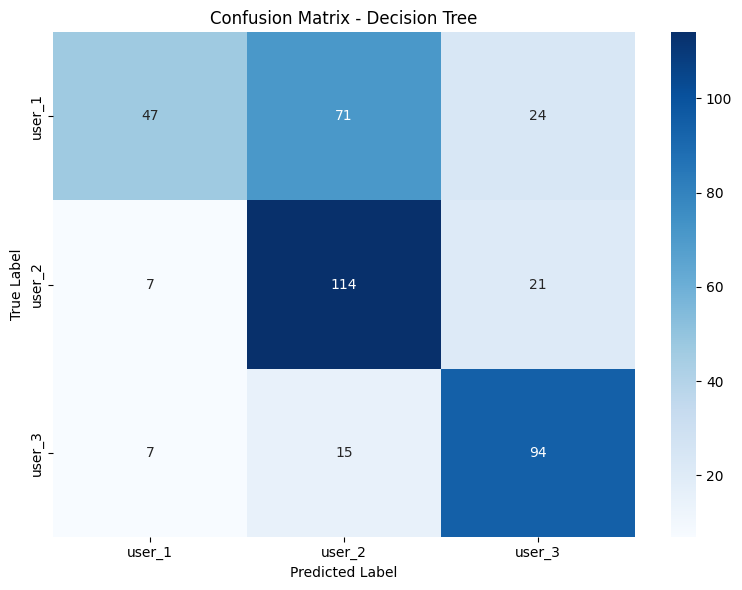


FEATURE IMPORTANCE
           feature  importance
0              age    0.543632
3  purchase_amount    0.394834
1           income    0.050254
2           clicks    0.011280


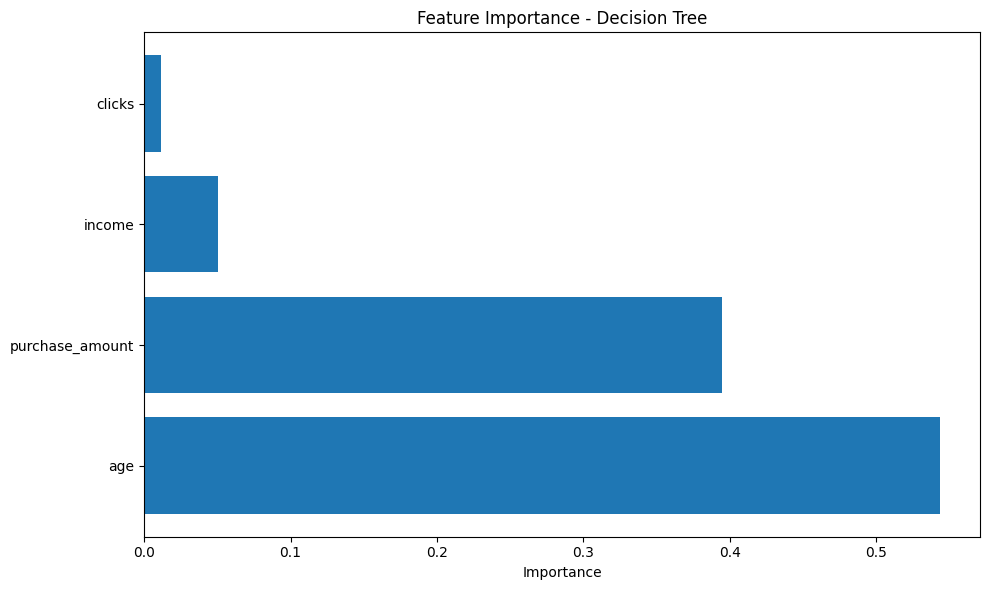


CONTEXT PREDICTOR TEST
Testing context predictor on first 5 validation samples:
Sample 1: Predicted=user_2, True=user_2, Match=✓
Sample 2: Predicted=user_2, True=user_1, Match=✗
Sample 3: Predicted=user_2, True=user_1, Match=✗
Sample 4: Predicted=user_2, True=user_2, Match=✓
Sample 5: Predicted=user_3, True=user_3, Match=✓


In [13]:
import seaborn as sns
print("CLASSIFICATION REPORT (Validation Set)")

print(classification_report(
    y_val_split, 
    results[best_classifier_name]['y_val_pred'],
    target_names=label_encoder.classes_
))
cm = confusion_matrix(y_val_split, results[best_classifier_name]['y_val_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_classifier_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

if hasattr(best_classifier, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_classifier.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE")
    print("="*60)
    print(feature_importance)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_classifier_name}')
    plt.tight_layout()
    plt.show()

def predict_user_context(user_features):
    """
    Predict user context (0=User1, 1=User2, 2=User3) from user features.
    
    Args:
        user_features: numpy array of shape (n_samples, 4) with columns:
                      [age, income, clicks, purchase_amount]
    
    Returns:
        Predicted context indices (0, 1, or 2)
    """
    return best_classifier.predict(user_features)

# Test the context predictor
print("\n" + "="*60)
print("CONTEXT PREDICTOR TEST")
print("="*60)
print("Testing context predictor on first 5 validation samples:")
test_features = X_val_split[:5]
predicted_contexts = predict_user_context(test_features)
true_contexts = y_val_split[:5]

for i, (pred, true) in enumerate(zip(predicted_contexts, true_contexts)):
    print(f"Sample {i+1}: Predicted={label_encoder.classes_[pred]}, "
          f"True={label_encoder.classes_[true]}, "
          f"Match={'✓' if pred == true else '✗'}")

EVALUATION ON TEST USERS (Context Detector)
No labels available in test set.
Generated 2000 predictions for test users

Predicted user distribution:
  user_1: 322 (16.1%)
  user_2: 993 (49.6%)
  user_3: 685 (34.2%)


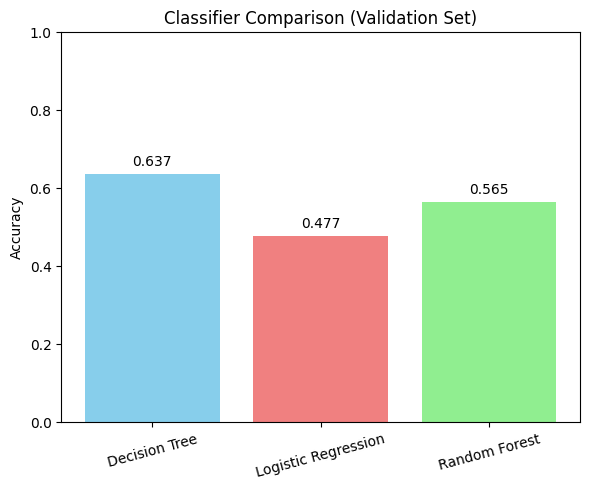

In [14]:

print("EVALUATION ON TEST USERS (Context Detector)")


# Predict contexts for test users
test_predictions = predict_user_context(X_test)

if y_test is not None:
    # If we have labels, evaluate accuracy
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Test Set Accuracy: {test_accuracy:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, test_predictions, target_names=label_encoder.classes_))
else:
    # If no labels, just show predictions
    print("No labels available in test set.")
    print(f"Generated {len(test_predictions)} predictions for test users")
    print(f"\nPredicted user distribution:")
    unique, counts = np.unique(test_predictions, return_counts=True)
    for label_idx, count in zip(unique, counts):
        print(f"  {label_encoder.classes_[label_idx]}: {count} ({count/len(test_predictions)*100:.1f}%)")


# Visualize prediction accuracy across different user types
if y_test is not None:
    plt.figure(figsize=(12, 5))

    # Plot 1: Accuracy comparison
    plt.subplot(1, 2, 1)
    accuracies = [results[name]['val_accuracy'] for name in classifiers.keys()]
    plt.bar(classifiers.keys(), accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.ylabel('Accuracy')
    plt.title('Classifier Comparison (Validation Set)')
    plt.xticks(rotation=15)
    plt.ylim([0, 1])
    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center')

    # Plot 2: Test set confusion matrix
    plt.subplot(1, 2, 2)
    cm_test = confusion_matrix(y_test, test_predictions)
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Test Set Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()
else:
    # Just show classifier comparison
    plt.figure(figsize=(6, 5))
    accuracies = [results[name]['val_accuracy'] for name in classifiers.keys()]
    plt.bar(classifiers.keys(), accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.ylabel('Accuracy')
    plt.title('Classifier Comparison (Validation Set)')
    plt.xticks(rotation=15)
    plt.ylim([0, 1])
    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center')
    plt.tight_layout()
    plt.show()


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach
